In [19]:
from typing import TypedDict

class PortfolioState(TypedDict):
    amount_usd: float
    total_usd: float
    total_inr: float

In [20]:
def cals_total(state: PortfolioState) -> PortfolioState:
    state['total_usd'] = state['amount_usd'] * 1.08
    return state

def convert_to_inr(state: PortfolioState) -> PortfolioState:
    state['total_inr'] = state['total_usd'] * 85
    return state

In [21]:
pip install langgraph

Note: you may need to restart the kernel to use updated packages.


In [22]:
from langgraph.graph import StateGraph , START , END

builder = StateGraph(ProtfolioState)

builder.add_node("cals_total_node",cals_total)
builder.add_node("con_to_inr",convert_to_inr)


builder.add_edge(START , "cals_total_node")
builder.add_edge( "cals_total_node","con_to_inr")
builder.add_edge("con_to_inr",END)


graph = builder.compile()

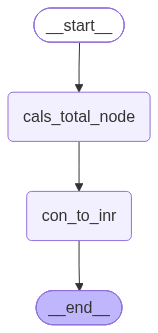

In [23]:
from IPython.display import Image , display

display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
graph.invoke({"amount_usd":1000})

{'amount_usd': 1000, 'total_usd': 1080.0, 'total_inr': 91800.0}